# Multi-Layer Perceptron implementation from scratch

### Imports

Loads the core libraries needed for the whole notebook — **numpy** for the vectorized math behind the model, **matplotlib** for visualization, and **load_breast_cancer** from scikit-learn as a real-data source.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

### Loading Data

Defines a from-scratch train/test split function (shuffles all row indices randomly, then slices off a portion as the test set), then loads the real Breast Cancer Wisconsin dataset using all 30 real tumor measurements as features, converts the diagnosis into a 1/0 column vector (malignant/benign), and applies the split.

In [3]:
def train_test_split_scratch(X, y, test_size=0.2, random_state=None):
    rng = np.random.RandomState(random_state)
    m = X.shape[0]
    shuffled_indices = rng.permutation(m)
    test_count = int(m * test_size)
    test_idx, train_idx = shuffled_indices[:test_count], shuffled_indices[test_count:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

data = load_breast_cancer(as_frame=True)
df = data.frame

X = df.drop(columns=["target"]).values.astype(float)
y = (1 - df["target"].values).reshape(-1, 1)  # 1 = malignant, 0 = benign

X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.2, random_state=2)

print(f"Training examples: {X_train.shape[0]}, Test examples: {X_test.shape[0]}, Features: {X_train.shape[1]}")

Training examples: 456, Test examples: 113, Features: 30


### Standardizing Features

Scales all 30 features to the same standardized range before training.

In [4]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

### Visualization

Plots two real features (mean radius, mean texture) colored by diagnosis, for a visual sense of class separation before training

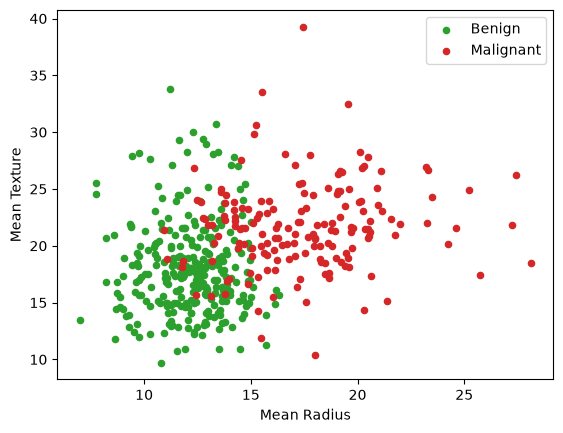

In [5]:
plt.scatter(X_train[y_train.ravel() == 0, 0], X_train[y_train.ravel() == 0, 1],
            color='tab:green', label='Benign', s=20)
plt.scatter(X_train[y_train.ravel() == 1, 0], X_train[y_train.ravel() == 1, 1],
            color='tab:red', label='Malignant', s=20)
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.legend()
plt.show()

### MLP Class

Implements a two-layer neural network from scratch: one hidden layer of 16 neurons with ReLU activation, followed by a single output neuron with sigmoid activation for binary classification. **forward** computes predictions layer by layer; **backward** implements manual backpropagation with the chain rule applied layer by layer, computing how much each weight in both layers contributed to the error, working backward from the output; **fit** runs this forward/backward cycle repeatedly, tracking loss each epoch.

In [6]:
class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim=1, learning_rate=0.1):
        rng = np.random.RandomState(2)
        self.W1 = rng.randn(input_dim, hidden_dim) * np.sqrt(2 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = rng.randn(hidden_dim, output_dim) * np.sqrt(2 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        self.learning_rate = learning_rate

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def compute_loss(self, y_pred, y_true):
        m = y_true.shape[0]
        eps = 1e-8
        return -(1 / m) * np.sum(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

    def backward(self, X, y_true):
        m = X.shape[0]

        dz2 = self.a2 - y_true
        dW2 = (1 / m) * self.a1.T @ dz2
        db2 = (1 / m) * np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_derivative(self.z1)
        dW1 = (1 / m) * X.T @ dz1
        db1 = (1 / m) * np.sum(dz1, axis=0, keepdims=True)

        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1

    def fit(self, X, y, epochs=1000):
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y_pred, y)
            losses.append(loss)
            self.backward(X, y)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss {loss:.4f}")

        return losses

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

### Training Model

Trains the network for 1000 epochs on the real training data, then measures accuracy on both the training set and the held-out test set.

In [7]:
mlp = MLP(input_dim=30, hidden_dim=16, learning_rate=0.1)
losses = mlp.fit(X_train_scaled, y_train, epochs=1000)

train_predictions = mlp.predict(X_train_scaled)
test_predictions = mlp.predict(X_test_scaled)

train_accuracy = np.mean(train_predictions == y_train) * 100
test_accuracy = np.mean(test_predictions == y_test) * 100

print(f"Train accuracy: {train_accuracy:.2f}%")
print(f"Test accuracy: {test_accuracy:.2f}%")

Epoch 0: Loss 1.5007
Epoch 100: Loss 0.0960
Epoch 200: Loss 0.0709
Epoch 300: Loss 0.0583
Epoch 400: Loss 0.0503
Epoch 500: Loss 0.0447
Epoch 600: Loss 0.0401
Epoch 700: Loss 0.0361
Epoch 800: Loss 0.0326
Epoch 900: Loss 0.0298
Train accuracy: 99.12%
Test accuracy: 94.69%


Loss drops steadily from **1.5007** to **0.0298** with no instability. **99.12% train accuracy**, **94.69% test accuracy**. The gap between the two suggests the model learned real patterns rather than simply memorizing the training data.

### Visualizing the Loss Curve

Plots the loss value recorded at every one of the 1000 training epochs.

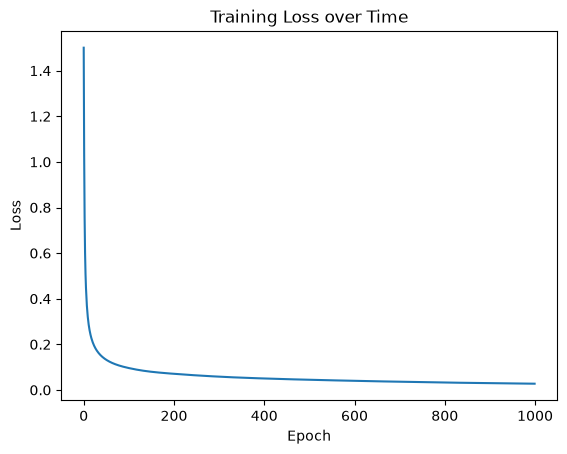

In [8]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.show()

A smooth, steadily decreasing curve with no jumps or plateaus followed by spikes, which is the expected signature of a correctly implemented backpropagation.

### PyTorch Validation

Fits an equivalent PyTorch model — same architecture (**Linear(30,16)** → **ReLU** → **Linear(16,1)** → **Sigmoid**), same loss function (binary cross-entropy), same plain SGD update rule, same learning rate and epoch count as an independent correctness check. The key difference from the from-scratch version: **loss.backward()** computes every gradient automatically via autograd, instead of the chain rule being derived and coded by hand.

In [9]:
import torch
import torch.nn as nn

torch.manual_seed(2)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

torch_mlp = nn.Sequential(
    nn.Linear(30, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(torch_mlp.parameters(), lr=0.1)

for epoch in range(1000):
    optimizer.zero_grad()
    outputs = torch_mlp(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    torch_test_preds = (torch_mlp(X_test_tensor) >= 0.5).float()
    torch_test_accuracy = (torch_test_preds == y_test_tensor).float().mean().item() * 100

print(f"From scratch: {test_accuracy:.2f}%")
print(f"PyTorch:      {torch_test_accuracy:.2f}%")

From scratch: 94.69%
PyTorch:      95.58%


**94.69% (from scratch) vs. 95.58% (PyTorch)**. Close but not identical, which is expected here: PyTorch's default weight initialization differs from the initialization used in the from-scratch version, and **torch.manual_seed** doesn't produce the same random sequence as NumPy's **RandomState** even with a matching seed number.